# Week 4b — Does Self-Forecasted Wind/Solar Actually Help the Demand Model?

The point of `notebooks/09`/`10` wasn't the capacity-factor accuracy for its own sake — it was to produce a genuinely deployable `wind`/`solar` feature for the demand model. This notebook closes the loop: three versions of the `1d` demand model, all evaluated on the identical `2024-03-07`-onward slice with day-ahead weather (the realistic setting established in `notebooks/08`):

1. **No wind/solar** — today's baseline (weather only, as in `notebooks/08`).
2. **Outturn wind/solar** — actual generation MW added as features. Not deployable (same-period actuals), but the theoretical ceiling.
3. **Self-forecasted wind/solar** — the `notebooks/09`/`10` capacity-factor models' own day-ahead-driven predictions, converted to MW, added as features instead. The actually-deployable version.

**Hypothesis:** Week 4's feature-importance finding already showed `wind_speed_ms`/`shortwave_radiation_wm2` ranking above `temperature_c` in the weather-only model — plausibly because they're already proxying for embedded generation's demand-suppression effect. If that's the whole story, adding wind/solar directly should add little on top of Model 1. If there's real signal beyond what the weather proxy captures (turbine curves, actual capacity, metered patterns), Model 2 should beat Model 1 by a real margin — and the open question is how much of that margin Model 3 recovers.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.data.weather import DAY_AHEAD_ARCHIVE_START
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.features.generation import (
    build_solar_feature_table,
    build_wind_feature_table,
)
from edf.features.weather import build_weather_feature_table
from edf.models.baselines import previous_week_same_time
from edf.models.forecast import train_lightgbm
from edf.models.tuning import tune_lightgbm, walk_forward_cv_folds
from edf.tracking import log_model_run

pd.options.display.float_format = "{:.4f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]

2026/09/07 11:42:09 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION
slice_start = str(DAY_AHEAD_ARCHIVE_START.date())

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
day_ahead = build_weather_feature_table("open_meteo_day_ahead", df.index, raw_dir=WEATHER_RAW_DIR)

seasonal_naive_val = previous_week_same_time(demand)
naive_mae_slice = evaluate(
    demand.loc[slice_start:val_end], seasonal_naive_val.loc[slice_start:val_end]
)["mae"]
naive_mae_slice

1857.4634722222222

## Step 1: generate self-forecasted wind/solar for the slice

Reuses the exact hyperparameters `notebooks/09`/`10` already found via walk-forward CV (re-tuning here would just rediscover the same values) — trained fresh on `TRAIN` using ERA5, predictions made with day-ahead weather fed in for the slice, then converted from capacity factor to MW.

In [3]:
WIND_PARAMS = {"num_leaves": 15, "min_child_samples": 50, "learning_rate": 0.1}
WIND_N_ESTIMATORS = 29
SOLAR_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.03}
SOLAR_N_ESTIMATORS = 136

X_wind, y_wind = build_wind_feature_table(df, era5)
wind_model = train_lightgbm(
    X_wind.loc[train_start:train_end], y_wind.loc[train_start:train_end],
    n_estimators=WIND_N_ESTIMATORS, **WIND_PARAMS,
)
X_wind_da, _ = build_wind_feature_table(df, day_ahead)
X_wind_da_slice = X_wind_da.loc[slice_start:val_end]
wind_cf_forecast = pd.Series(wind_model.predict(X_wind_da_slice), index=X_wind_da_slice.index)
wind_mw_forecast = wind_cf_forecast * df.loc[wind_cf_forecast.index, "wind_capacity"]

X_solar, y_solar = build_solar_feature_table(df, era5)
solar_model = train_lightgbm(
    X_solar.loc[train_start:train_end], y_solar.loc[train_start:train_end],
    n_estimators=SOLAR_N_ESTIMATORS, **SOLAR_PARAMS,
)
X_solar_da, _ = build_solar_feature_table(df, day_ahead)
X_solar_da_slice = X_solar_da.loc[slice_start:val_end]
solar_cf_forecast = pd.Series(solar_model.predict(X_solar_da_slice), index=X_solar_da_slice.index)
solar_mw_forecast = solar_cf_forecast * df.loc[solar_cf_forecast.index, "solar_capacity"]

gen_forecast = pd.DataFrame({"wind": wind_mw_forecast, "solar": solar_mw_forecast})
gen_forecast.describe()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 70128, number of used features: 16
[LightGBM] [Info] Start training from score 0.285018
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 70128, number of used features: 18
[LightGBM] [Info] Start training from score 0.100912


,wind,solar
count,14400.0000,14400.0000
mean,1706.8005,1999.2878
std,874.9081,2735.3329
min,653.5550,24.1817
25%,1001.5225,33.1573
50%,1504.1440,140.0201
75%,2193.5508,3638.9045
max,4866.7414,11509.6300


## Sanity check: self-forecasted vs. outturn wind/solar, one week

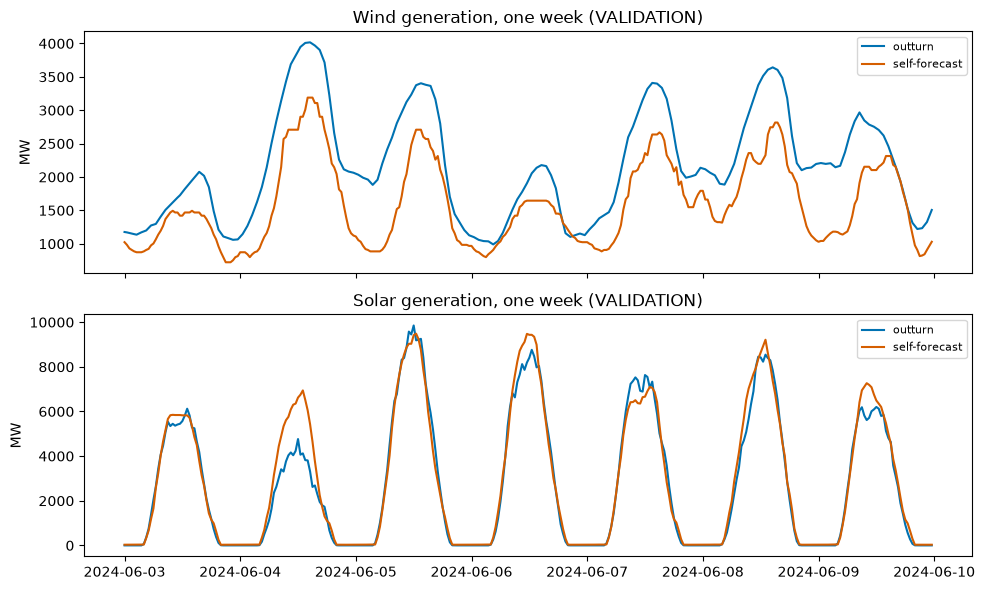

In [4]:
window = slice("2024-06-03", "2024-06-09")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, col, title in zip(axes, ["wind", "solar"], ["Wind", "Solar"]):
    ax.plot(df.loc[window].index, df.loc[window, col], label="outturn", color="#0072B2")
    ax.plot(gen_forecast.loc[window].index, gen_forecast.loc[window, col], label="self-forecast", color="#D55E00")
    ax.set_title(f"{title} generation, one week (VALIDATION)")
    ax.set_ylabel("MW")
    ax.legend(fontsize=8)
fig.tight_layout()

## What this plot already tells us

Solar's self-forecast tracks outturn tightly (consistent with `notebooks/10`'s tight fit). Wind's self-forecast is **systematically low across the whole week**, not just at peaks — e.g. 2024-06-04's peak reaches ≈4000 MW outturn vs. ≈3200 MW self-forecast, and this gap persists at nearly every hour, not only the extremes (`notebooks/09` already flagged the peak-specific version of this). That's worth keeping in mind before the demand-model comparison below: whatever `wind` contributes as a feature, the self-forecast version of it is a visibly noisy, biased signal, not a clean stand-in for the real thing.

## Model 1: no wind/solar (weather only)

In [5]:
def tune_and_train(X, y, tag):
    X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
    folds = walk_forward_cv_folds(X_train.index)
    t0 = time.time()
    best_params, best_n, _trials = tune_lightgbm(X_train, y_train, folds, n_trials=10)
    tune_seconds = time.time() - t0
    model = train_lightgbm(X_train, y_train, n_estimators=best_n, **best_params)
    print(f"{tag}: {best_params}, n_estimators={best_n}, tune={tune_seconds:.0f}s")
    return model, best_params, best_n, tune_seconds

X_no_gen, y_demand = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5)
model_no_gen, params_no_gen, n_no_gen, tune_no_gen_s = tune_and_train(X_no_gen, y_demand, "no wind/solar")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 27549.082918


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000941 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 26931.631382


no wind/solar: {'num_leaves': 15, 'min_child_samples': 20, 'learning_rate': 0.05}, n_estimators=689, tune=180s


## Model 2: with wind/solar (trained on outturn values — the only ones available for `TRAIN`)

In [6]:
X_with_gen = X_no_gen.join(df[["wind", "solar"]])
model_with_gen, params_with_gen, n_with_gen, tune_with_gen_s = tune_and_train(
    X_with_gen, y_demand, "with wind/solar (outturn-trained)"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6083
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 31
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6185
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 31
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6200
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 31
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6083
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 31
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6185
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 31
[LightGBM] [Info] Start training from score 27549.082918


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6083
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 31
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6185
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 31
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6200
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 31
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6201
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 31
[LightGBM] [Info] Start training from score 26931.631382


with wind/solar (outturn-trained): {'num_leaves': 15, 'min_child_samples': 20, 'learning_rate': 0.05}, n_estimators=846, tune=322s


## Evaluate all three on the identical slice, identical target rows

In [7]:
X_da_no_gen, y_da_no_gen = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=day_ahead)
X_slice_no_gen = X_da_no_gen.loc[slice_start:val_end]
y_slice = y_da_no_gen.loc[slice_start:val_end]

preds_no_gen = pd.Series(model_no_gen.predict(X_slice_no_gen), index=X_slice_no_gen.index)

X_slice_outturn_gen = X_slice_no_gen.assign(
    wind=df.loc[X_slice_no_gen.index, "wind"], solar=df.loc[X_slice_no_gen.index, "solar"]
)
preds_outturn_gen = pd.Series(model_with_gen.predict(X_slice_outturn_gen), index=X_slice_no_gen.index)

X_slice_forecast_gen = X_slice_no_gen.assign(
    wind=gen_forecast.loc[X_slice_no_gen.index, "wind"], solar=gen_forecast.loc[X_slice_no_gen.index, "solar"]
)
preds_forecast_gen = pd.Series(model_with_gen.predict(X_slice_forecast_gen), index=X_slice_no_gen.index)

results = pd.DataFrame(
    {
        "no_wind_solar": evaluate(y_slice, preds_no_gen, seasonal_naive_mae=naive_mae_slice),
        "outturn_wind_solar": evaluate(y_slice, preds_outturn_gen, seasonal_naive_mae=naive_mae_slice),
        "self_forecast_wind_solar": evaluate(y_slice, preds_forecast_gen, seasonal_naive_mae=naive_mae_slice),
    }
).T
results["mae_improvement_pct"] = (
    (results.loc["no_wind_solar", "mae"] - results["mae"]) / results.loc["no_wind_solar", "mae"] * 100
)
print(f"Slice: {slice_start} to {val_end}, n={len(y_slice)}")
results

Slice: 2024-03-07 to 2024-12-31, n=14400


,mae,rmse,mape,bias,p95_abs_error,n,mase,mae_improvement_pct
no_wind_solar,877.4634,1155.7861,3.5381,-7.2239,2395.1264,14400.0000,0.4724,0.0000
outturn_wind_solar,680.6000,887.9231,2.7127,158.0977,1828.8720,14400.0000,0.3664,22.4355
self_forecast_wind_solar,876.7078,1165.6160,3.5008,206.8058,2390.8731,14400.0000,0.4720,0.0861


## Finding: the real gain is real — and self-forecasting doesn't recover it

| model | MAE | MASE | improvement vs. no-wind/solar |
|---|---|---|---|
| no wind/solar | 877.5 | 0.472 | — |
| **outturn** wind/solar | 680.6 | **0.366** | **22.4%** |
| **self-forecast** wind/solar | 876.7 | 0.472 | **0.09%** |

The theoretical ceiling is real and substantial: outturn wind/solar cuts MAE by 22.4% on top of the weather-only model — genuine additional signal beyond what `wind_speed_ms`/`shortwave_radiation_wm2` already proxy for (Week 4's finding). But **the self-forecast version recovers essentially none of it** — 0.09% improvement is noise, not signal; MASE is identical to three decimal places.

Two compounding reasons, both visible in this notebook already:
1. **The self-forecast itself is too noisy to help.** The sanity-check plot above shows wind's self-forecast running systematically low across an entire week, not just at extremes — that's a lot of error to hand the demand model as a "feature."
2. **Some of the outturn gain may not be weather-forecastable at all, even with a perfect wind/solar model.** Actual metered generation reflects things weather alone can't predict — curtailment, mechanical outages, dispatch decisions — which is exactly the kind of information a weather-driven capacity-factor model has no way to see coming. If that's a meaningful share of the 22.4%, no amount of improving the *weather* input would close it.

**This closes the loop from Week 4 in a satisfying way**: Week 4 found that weather variables (wind speed, shortwave radiation) already proxy for embedded generation's demand-suppression effect. This result explains *why* trying to go further — directly forecasting the generation itself — doesn't pay off in practice: the weather proxy was already capturing essentially all of the weather-explainable part, and what's left over either needs a much more accurate generation forecast than a simple weather-driven model can deliver, or isn't forecastable from weather at all. **Recommendation: don't add self-forecasted wind/solar to the deployed demand model** — the accuracy cost of the forecast error outweighs any signal it adds; keep the weather features from Week 4 instead.

## Feature importance: where do `wind`/`solar` rank in Model 2?

wind: rank 7 / 32
solar: rank 4 / 32


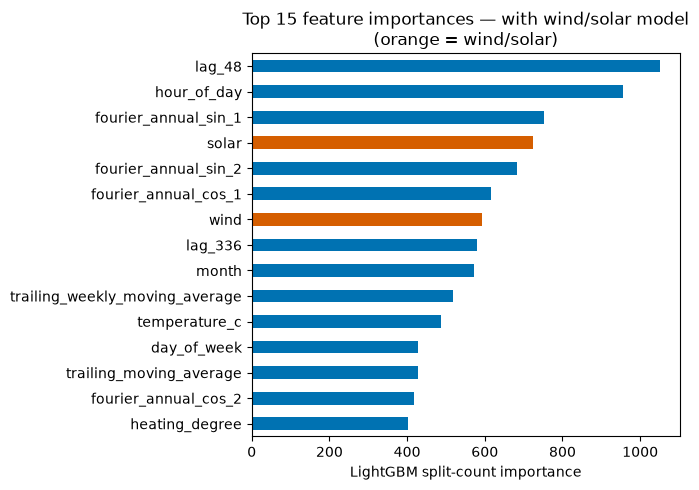

In [8]:
importance = (
    pd.Series(model_with_gen.feature_importances_, index=model_with_gen.feature_name_)
    .sort_values(ascending=False)
)
colors_imp = ["#D55E00" if c in ("wind", "solar") else "#0072B2" for c in importance.index[:15]]

fig, ax = plt.subplots(figsize=(7, 5))
importance.head(15).iloc[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
ax.set_title("Top 15 feature importances — with wind/solar model\n(orange = wind/solar)")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

ranks = {name: rank + 1 for rank, name in enumerate(importance.index)}
print(f"wind: rank {ranks['wind']} / {len(importance)}")
print(f"solar: rank {ranks['solar']} / {len(importance)}")

## Note on feature importance vs. the mlflow accuracy — a real pitfall to flag

`solar` (rank 4/32) and `wind` (rank 7/32) both rank *highly* in Model 2's importance — which could easily be read as "wind/solar matter a lot," and in a sense they do, **for Model 2 specifically, when fed outturn values**. But feature importance describes what a model *learned to lean on*, not what a *deployable* version of that model can actually achieve — Model 2 was trained on outturn wind/solar, and this importance ranking is faithful to that training regime. It says nothing about how well `wind`/`solar` predict demand when they're themselves only forecasts. The comparison table above is the number that matters for a deployment decision; this importance chart, read on its own, would be actively misleading about that.

## Log all three variants to MLflow

In [9]:
for tag, metrics in [
    ("no_wind_solar", results.loc["no_wind_solar"]),
    ("outturn_wind_solar", results.loc["outturn_wind_solar"]),
    ("self_forecast_wind_solar", results.loc["self_forecast_wind_solar"]),
]:
    fold_metrics = pd.DataFrame(
        [metrics.drop("mae_improvement_pct")], index=pd.Index([2024], name="year")
    )
    log_model_run(
        horizon_name="1d",
        horizon_periods=HORIZON_PERIODS,
        model_name="lightgbm",
        fold_metrics=fold_metrics,
        extra_tags={"strategy": "direct", "tuned": "true", "generation_features": tag},
    )
print("Logged all three variants to MLflow (forecast-1d experiment)")

Logged all three variants to MLflow (forecast-1d experiment)
